### MEDICAL INSURANCE PROJECT
### CENTRE FOR DATA ANALYTICS AND MODELLING (CDAM)
### BY CANON TUMWET
### DATA ANALYST

# ***MEDICAL INSURANCE PROJECT***

## **Project Summary**  
### This Python-based project explores the key drivers of medical insurance costs using a real-world healthcare dataset. The process involves loading, cleaning, and inspecting the data with pandas, followed by exploratory data analysis (EDA) using visualizations like histograms, boxplots, and correlation heatmaps. Categorical variables (sex, smoker status, region) will be numerically encoded to prepare for modeling. You will then build and evaluate two predictive models: a simple linear regression (using BMI) and a multiple linear regression (incorporating age, BMI, children, and demographic factors). The project concludes with a comparative performance analysis and a concise report answering critical questions about cost drivers, model effectiveness, and limitations. Ideal for learners, this hands-on exercise strengthens core data science skills in data wrangling, visualization, and regression modeling using Python.

## *Setup and data loading*

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import pingouin as pg 
import statsmodels.api as sm

## Load dataset

In [2]:
data=pd.read_csv("insurance.csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Initial inspection

In [3]:
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [4]:
data.shape

(1338, 7)

In [5]:
data.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [6]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Data Cleaning & Validation

### Data cleaning involves handling missing values, removing duplicates, and standardizing formats. It ensures accurate, reliable analysis by eliminating errors that could skew insights, statistical validity, and downstream modeling outcomes.

## Check missing values

In [7]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### The dataset contained zero missing values

## Remove duplicates

In [8]:
data.duplicated().sum() 

np.int64(1)

In [9]:
data.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## *Exploratory Data Analysis*

### EDA helps uncovers patterns, detects anomalies, tests assumptions, and identifies relationships between variables through visualizations and summary statistics. It guides feature selection, informs cleaning decisions, and generates hypotheses ensuring deeper, data-driven insights before modeling or decision-making.

### Histogram/KDE of charges; Assess skewness, outliers

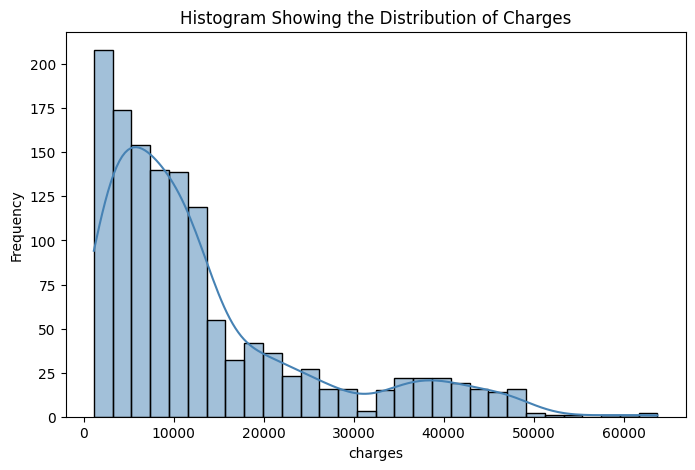

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(data['charges'], bins=30, kde=True, color='steelblue')
plt.title("Histogram Showing the Distribution of Charges")
plt.xlabel("charges")
plt.ylabel("Frequency")
plt.show()

### Boxplots: charges by smoker, sex, region, compare group distributions

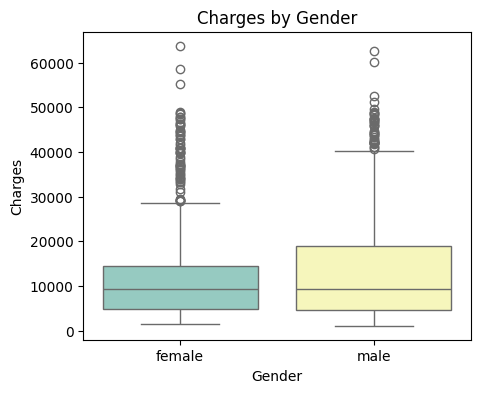

In [12]:
plt.figure(figsize=(5,4))
sns.boxplot(data=data, x='sex', y='charges', palette="Set3")
plt.title("Charges by Gender")
plt.xlabel("Gender")
plt.ylabel("Charges")
plt.show()

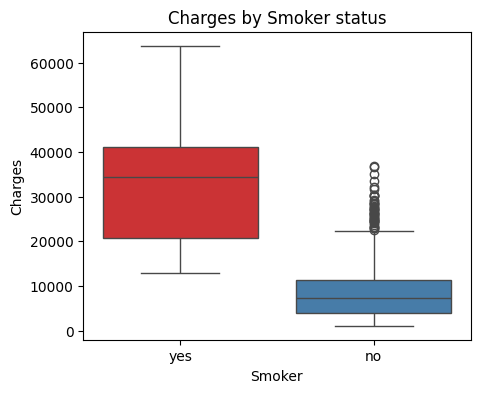

In [13]:
plt.figure(figsize=(5,4))
sns.boxplot(data=data, x='smoker', y='charges', palette="Set1")
plt.title("Charges by Smoker status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

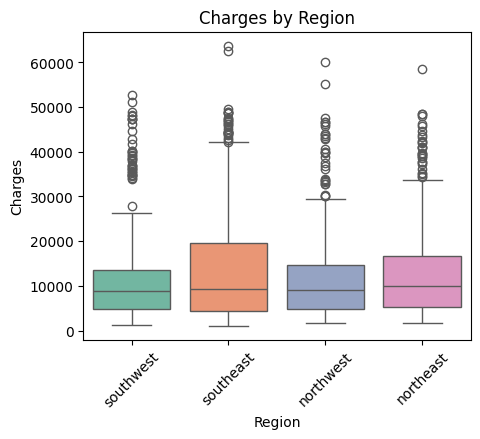

In [14]:
plt.figure(figsize=(5,4))
sns.boxplot(data=data, x='region', y='charges', palette="Set2")
plt.title("Charges by Region")
plt.xlabel("Region")
plt.ylabel("Charges")
plt.xticks(rotation=45)
plt.show()

### Scatterplots: age vs charges, bmi vs charges; spot trends/non-linearity

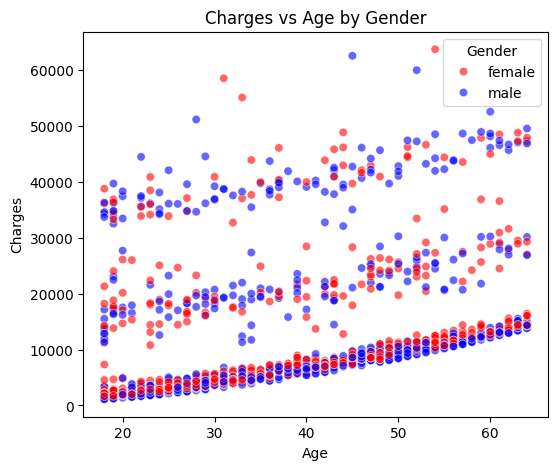

In [15]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=data, x='age', y='charges', hue='sex', alpha=0.6, palette=['red', 'blue'])
plt.title("Charges vs Age by Gender")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.legend(title='Gender')
plt.show()

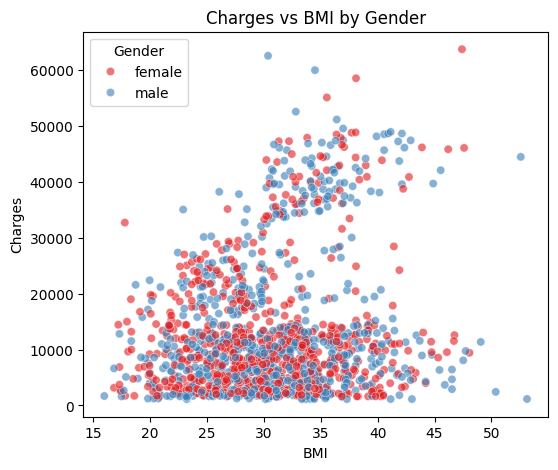

In [16]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=data, x='bmi', y='charges', hue='sex', alpha=0.6, palette="Set1")
plt.title("Charges vs BMI by Gender")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.legend(title='Gender')
plt.show()

### Correlation heatmap (numeric vars only): Identify linear relationships

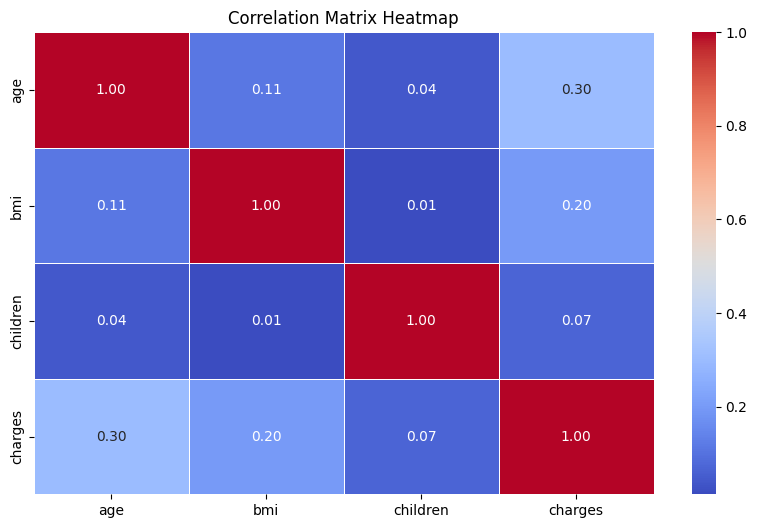

In [17]:
plt.figure(figsize=(10, 6))
corr_matrix = data.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

### Grouped bar charts: avg. charges by region + smoker interaction

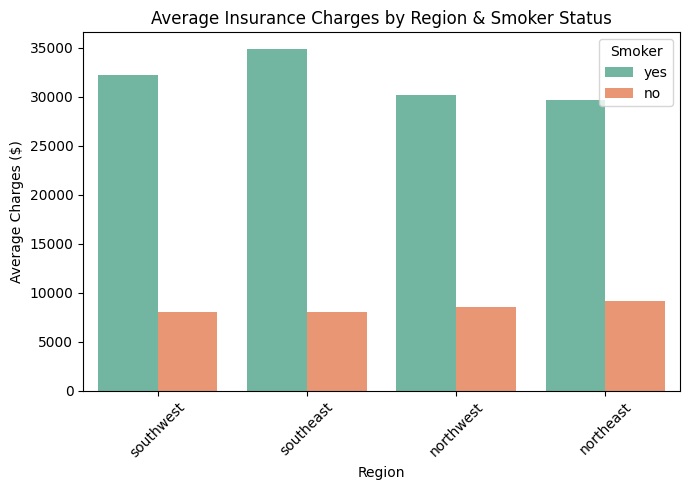

In [18]:
plt.figure(figsize=(7,5))
sns.barplot(data=data, x='region', y='charges', hue='smoker', 
            estimator='mean', errorbar=None, palette='Set2')
plt.title('Average Insurance Charges by Region & Smoker Status')
plt.ylabel('Average Charges ($)')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

## StatisticalTest

### These statistical checks validate observed patterns with quantitative evidence. The t-test determines if the charge difference between smokers and non-smokers is statistically significant, not due to chance. ANOVA assesses whether average charges vary meaningfully across regions. Correlation coefficients quantify the strength and direction of linear relationships between numerical features (age, BMI, children) and charges. Together, they move analysis beyond visuals providing rigor, supporting hypotheses, and guiding which factors truly warrant attention in decision-making or further modeling.

### Do smokers have significantly higher charges?
### HO: There is no significant difference between smoker status and total charges
### H1: There is significant difference between smoker status and total charges

In [19]:
group_A = data[data["smoker"] == "yes"]["charges"]
group_B = data[data["smoker"] == "no"]['charges']

two_sample_test = pg.ttest(group_A, group_B, paired=False)
two_sample_test

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,32.751888,311.851125,two-sided,5.889464e-103,"[22197.21, 25034.71]",3.161349,1.0,9.283e+168


### Do charges differ significantly across regions? 

In [20]:
anova_results = pg.anova(dv='charges', between='region', data=data)
anova_results

,Source,ddof1,ddof2,F,p_unc,np2
0,region,3,1334,2.969627,0.030893,0.006634


### Correlation coefficients

In [21]:
data[['age','bmi','children','charges']].corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


## Linear Regression Model
### Simple linear regression model
#### Simple Linear Regression models the relationship between one predictor (e.g., BMI) and a target variable (charges) using a straight line. It quantifies how changes in the predictor affect costs, providing interpretable coefficients, R-squared, and p-values to assess strength and significance.

In [22]:
X = sm.add_constant(data['bmi'])
y = data['charges']
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.71
Date:                Fri, 22 May 2026   Prob (F-statistic):           2.46e-13
Time:                        12:33:31   Log-Likelihood:                -14451.
No. Observations:                1338   AIC:                         2.891e+04
Df Residuals:                    1336   BIC:                         2.892e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1192.9372   1664.802      0.717      0.4

## Multiple Linear Regression
### Multiple Linear Regression models how several predictors age, BMI, children, and encoded demographics collectively influence insurance charges. Unlike simple regression, it captures combined effects, improving accuracy. By quantifying each variable's unique contribution while controlling for others, it reveals which factors truly drive healthcare costs.

In [27]:
data['charges'] = pd.to_numeric(data['charges'], errors='coerce')
df_enc = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)
X = df_enc.drop(columns=['charges']).astype(float)
y = df_enc['charges'].astype(float)
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Fri, 22 May 2026   Prob (F-statistic):               0.00
Time:                        12:35:28   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

### Project Summary

### From the results, smoking significantly increases charges, as evidenced by the `smoker_yes` coefficient of ~23,850 and a p-value of 0.000, confirming a highly significant cost premium. Among all predictors, smoking exerts the strongest influence due to its exceptionally large coefficient, far outweighing age, BMI, and children. Multiple regression is definitively better than simple regression because it simultaneously accounts for multiple confounding variables, reducing omitted-variable bias and yielding a more accurate, comprehensive model. By isolating each factor’s unique contribution while holding others constant, the multiple approach provides clearer, more reliable insights into true cost drivers than a single-variable model could achieve.